In [1]:
!pip install tensorflow scikit-learn matplotlib seaborn pandas requests pillow


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from google.colab import files
uploaded = files.upload()

import zipfile
with zipfile.ZipFile("weather_train.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset Extracted")

ModuleNotFoundError: No module named 'files'

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

dataset_path = "dataset/weather_train"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(train_data, validation_data=val_data, epochs=5)

model.save("weather_cnn_model.h5")

print("Model Training Completed")

Found 628 images belonging to 2 classes.
Found 155 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.7600 - loss: 0.6504 - val_accuracy: 1.0000 - val_loss: 0.0068
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9881 - loss: 0.0234 - val_accuracy: 0.9935 - val_loss: 0.0103
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9972 - loss: 0.0104 - val_accuracy: 1.0000 - val_loss: 9.5400e-04
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9988 - loss: 0.0036 - val_accuracy: 1.0000 - val_loss: 0.0036
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 0.0047


Model Training Completed


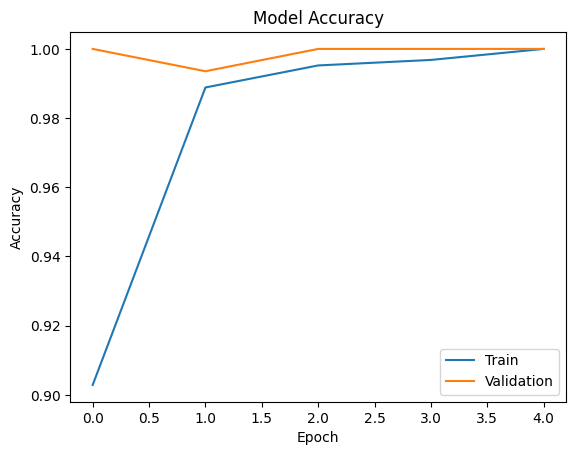

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

In [ ]:
pip install tensorflow pillow requests geopy

In [ ]:
!pip install tensorflow requests pillow geopy numpy matplotlib


--- REAL-TIME INDIA WEATHER & SATELLITE VIEWER ---
Enter an Indian city or state: chandigarh
📡 Downloading satellite imagery for chandigarh...
📊 Fetching 7-day weather forecast...

══════════════════════════════════════════════════════════════════════════════════════════
  LOCATION: CHANDIGARH (Lat: 30.73, Lon: 76.78)
══════════════════════════════════════════════════════════════════════════════════════════
DATE         | PATTERN              | MAX    | MIN    | RAIN   | WIND   | SUNRISE | SUNSET
──────────────────────────────────────────────────────────────────────────────────────────
2026-04-29   | 🌧️ Moderate Drizzle  | 34.0°C  | 21.0°C  | 1.7mm | 13.1km/h | 05:40 | 18:59
2026-04-30   | 🌧️ Slight Rain       | 30.6°C  | 20.4°C  | 1.9mm | 18.8km/h | 05:39 | 19:00
2026-05-01   | ⛅ Partly Cloudy      | 33.2°C  | 19.4°C  | 0.0mm | 15.6km/h | 05:38 | 19:00
2026-05-02   | ⛅ Partly Cloudy      | 35.8°C  | 19.0°C  | 0.0mm | 15.8km/h | 05:37 | 19:01
2026-05-03   | ☁️ Overcast          | 35.8

/tmp/ipykernel_3776/1690560395.py:119: UserWarning: Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


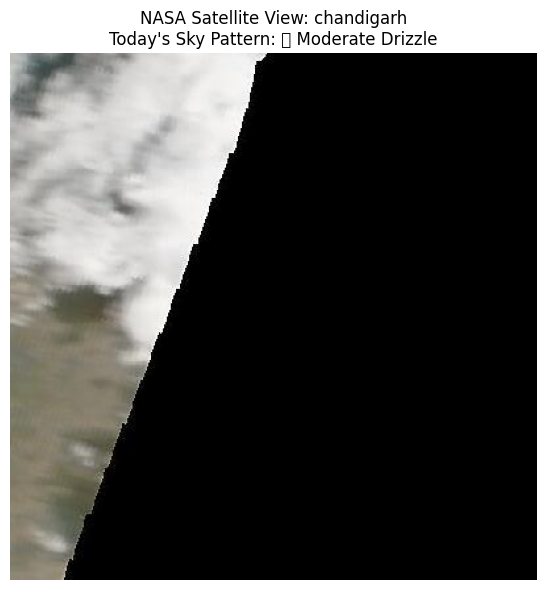

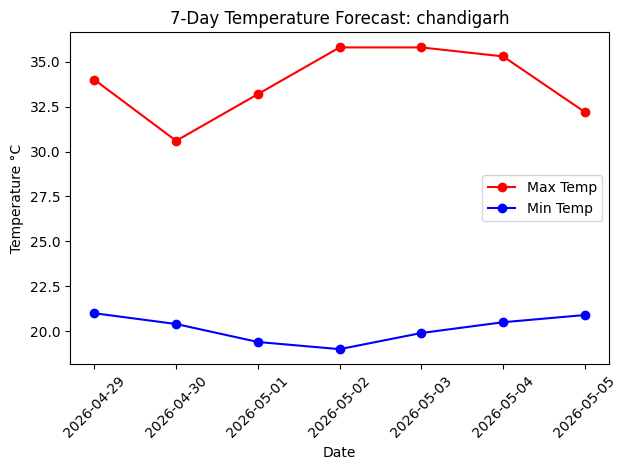

 City map saved as chandigarh_map.html


In [1]:
import requests
from PIL import Image
from io import BytesIO
from geopy.geocoders import Nominatim
from datetime import datetime
import matplotlib.pyplot as plt
import os
import folium

def get_lat_lon(place):
    geolocator = Nominatim(user_agent="india_weather_final")
    location = geolocator.geocode(place + ", India")
    if location is None:
        # fallback: try without ', India'
        location = geolocator.geocode(place)
        if location is None:
            raise Exception("City or State not found in India. Please check spelling.")
    return location.latitude, location.longitude

def fetch_satellite_image(lat, lon):
    filename = f"satellite_{lat:.2f}_{lon:.2f}.jpg"
    if os.path.exists(filename):
        return Image.open(filename)

    url = (
        "https://gibs.earthdata.nasa.gov/wms/epsg4326/best/wms.cgi?"
        "SERVICE=WMS&REQUEST=GetMap&VERSION=1.3.0"
        "&LAYERS=MODIS_Terra_CorrectedReflectance_TrueColor"
        "&FORMAT=image/jpeg&WIDTH=400&HEIGHT=400&CRS=EPSG:4326"
        f"&BBOX={lat-0.5},{lon-0.5},{lat+0.5},{lon+0.5}"
    )
    r = requests.get(url, timeout=15)
    if r.status_code != 200:
        raise Exception("Could not fetch NASA satellite image.")

    img = Image.open(BytesIO(r.content)).convert("RGB")
    img.save(filename)
    return img

def interpret_wmo_code(code):
    mapping = {
        0: " Clear Sky", 1: " Mainly Clear", 2: " Partly Cloudy", 3: " Overcast",
        45: " Foggy", 48: " Rime Fog",
        51: " Light Drizzle", 53: " Moderate Drizzle", 55: " Dense Drizzle",
        61: " Slight Rain", 63: " Moderate Rain", 65: " Heavy Rain",
        71: " Slight Snow", 73: " Moderate Snow", 75: " Heavy Snow",
        80: " Slight Showers", 81: " Moderate Showers", 82: " Violent Showers",
        95: " Thunderstorm", 96: " Thunderstorm w/ Hail", 99: " Heavy Thunderstorm"
    }
    return mapping.get(code, " Unknown")

def get_7day_weather(lat, lon):
    url = (
        f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}"
        "&daily=weather_code,temperature_2m_max,temperature_2m_min,"
        "precipitation_sum,windspeed_10m_max,sunrise,sunset&timezone=auto"
    )
    r = requests.get(url, timeout=10)
    data = r.json().get("daily", {})

    forecast_results = []
    for i in range(len(data.get("time", []))):
        day_info = {
            "date": data["time"][i],
            "pattern": interpret_wmo_code(data["weather_code"][i]),
            "t_max": data["temperature_2m_max"][i],
            "t_min": data["temperature_2m_min"][i],
            "rain": data["precipitation_sum"][i],
            "wind": data["windspeed_10m_max"][i],
            "sunrise": data["sunrise"][i].split("T")[1],
            "sunset": data["sunset"][i].split("T")[1]
        }
        forecast_results.append(day_info)
    return forecast_results

def create_city_map(lat, lon, city):
    map_file = f"{city}_map.html"
    m = folium.Map(location=[lat, lon], zoom_start=6)
    folium.Marker([lat, lon], popup=city).add_to(m)
    m.save(map_file)
    print(f" City map saved as {map_file}")

try:
    print("\n--- REAL-TIME INDIA WEATHER & SATELLITE VIEWER ---")
    city_input = input("Enter an Indian city or state: ").strip()

    lat, lon = get_lat_lon(city_input)

    try:
        print(f" Downloading satellite imagery for {city_input}...")
        sat_img = fetch_satellite_image(lat, lon)
    except Exception as e:
        print("Satellite image unavailable:", e)
        sat_img = None

    try:
        print(f"Fetching 7-day weather forecast...")
        forecast = get_7day_weather(lat, lon)
    except Exception as e:
        print("Weather data unavailable:", e)
        forecast = []

    if forecast:
        print("\n" + "═"*90)
        print(f"  LOCATION: {city_input.upper()} (Lat: {lat:.2f}, Lon: {lon:.2f})")
        print("═"*90)
        print(f"{'DATE':<12} | {'PATTERN':<20} | {'MAX':<6} | {'MIN':<6} | {'RAIN':<6} | {'WIND':<6} | {'SUNRISE':<6} | {'SUNSET':<6}")
        print("─"*90)
        for day in forecast:
            print(f"{day['date']:<12} | {day['pattern']:<20} | {day['t_max']}°C  | {day['t_min']}°C  | "
                  f"{day['rain']}mm | {day['wind']}km/h | {day['sunrise']} | {day['sunset']}")
        print("═"*90)

    if sat_img:
        plt.figure(figsize=(6,6))
        plt.imshow(sat_img)
        plt.title(f"NASA Satellite View: {city_input}\nToday's Sky Pattern: {forecast[0]['pattern'] if forecast else 'N/A'}")
        plt.axis("off")
        plt.tight_layout()
        plt.show()


    if forecast:
        dates = [day['date'] for day in forecast]
        t_max = [day['t_max'] for day in forecast]
        t_min = [day['t_min'] for day in forecast]

        plt.plot(dates, t_max, 'r-o', label='Max Temp')
        plt.plot(dates, t_min, 'b-o', label='Min Temp')
        plt.title(f"7-Day Temperature Forecast: {city_input}")
        plt.xlabel("Date")
        plt.ylabel("Temperature °C")
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    create_city_map(lat, lon, city_input)

except Exception as e:
    print(f"\n Error encountered: {e}")